## 1. IMPORTACIÓN Y CONFIGURACIÓN

In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from datetime import datetime
from dateutil.relativedelta import relativedelta
import pylab as py

# Librerías para modelos estadísticos
import statsmodels.api as sm
from scipy import stats

# Librerías para ARIMA y validación
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, linear_reset
from statsmodels.sandbox.stats.runs import runstest_1samp
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Librerías para métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Optimización
import optuna

# pmdarima
import pmdarima
from pmdarima.arima import auto_arima
from pmdarima.utils import acf, pacf

# Configuración de gráficos personalizada
import config_graficos_simple

# Configuraciones adicionales
warnings.filterwarnings('ignore')

print(f"Fecha de análisis: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Fecha de análisis: 2025-12-06 23:24


## 2. CARGA DE DATOS

In [2]:
# Cargar datos del análisis exploratorio
try:
    with open('datasets_preparados.pkl', 'rb') as f:
        datasets = pickle.load(f)
    
    # Extraer datasets
    data = datasets['data']
    train_to1 = datasets['train_to1']
    train_to2 = datasets['train_to2']
    test_to1 = datasets['test_to1']
    test_to2 = datasets['test_to2']
    train_len = datasets['train_len']
    
    print("Datos cargados exitosamente")
    print(f"Configuración: {train_len} train / {len(data) - train_len} test")
    
except FileNotFoundError:
    print("Error: No se encontró 'datasets_preparados.pkl'")
    print("Ejecuta primero el notebook '01_Analisis_Exploratorio.ipynb'")

Datos cargados exitosamente
Configuración: 121 train / 6 test


## 3. ANÁLISIS ARIMA - PRODUCTO 1

### 3.1 Análisis de Autocorrelación

In [3]:
acf(train_to1,100)

array([ 1.00000000e+00,  9.66798159e-01,  9.33712864e-01,  8.96584749e-01,
        8.57840168e-01,  8.14998408e-01,  7.72234713e-01,  7.28126321e-01,
        6.84095803e-01,  6.43734259e-01,  6.02138146e-01,  5.65686290e-01,
        5.27306722e-01,  4.90968039e-01,  4.52593065e-01,  4.14717732e-01,
        3.79530298e-01,  3.45480077e-01,  3.13169425e-01,  2.83266768e-01,
        2.56345898e-01,  2.31695504e-01,  2.10603575e-01,  1.93165688e-01,
        1.78585308e-01,  1.67253029e-01,  1.54978261e-01,  1.48316469e-01,
        1.39036507e-01,  1.34183856e-01,  1.26464285e-01,  1.20326349e-01,
        1.12348078e-01,  1.07627351e-01,  1.01296142e-01,  9.51164669e-02,
        8.78446123e-02,  7.92279167e-02,  6.84509300e-02,  5.52735377e-02,
        4.26454807e-02,  2.94288716e-02,  1.46767345e-02, -3.36851365e-04,
       -1.46495196e-02, -2.80004801e-02, -3.89363056e-02, -5.25572824e-02,
       -6.32711633e-02, -7.53595563e-02, -8.87085784e-02, -1.02502363e-01,
       -1.16586297e-01, -

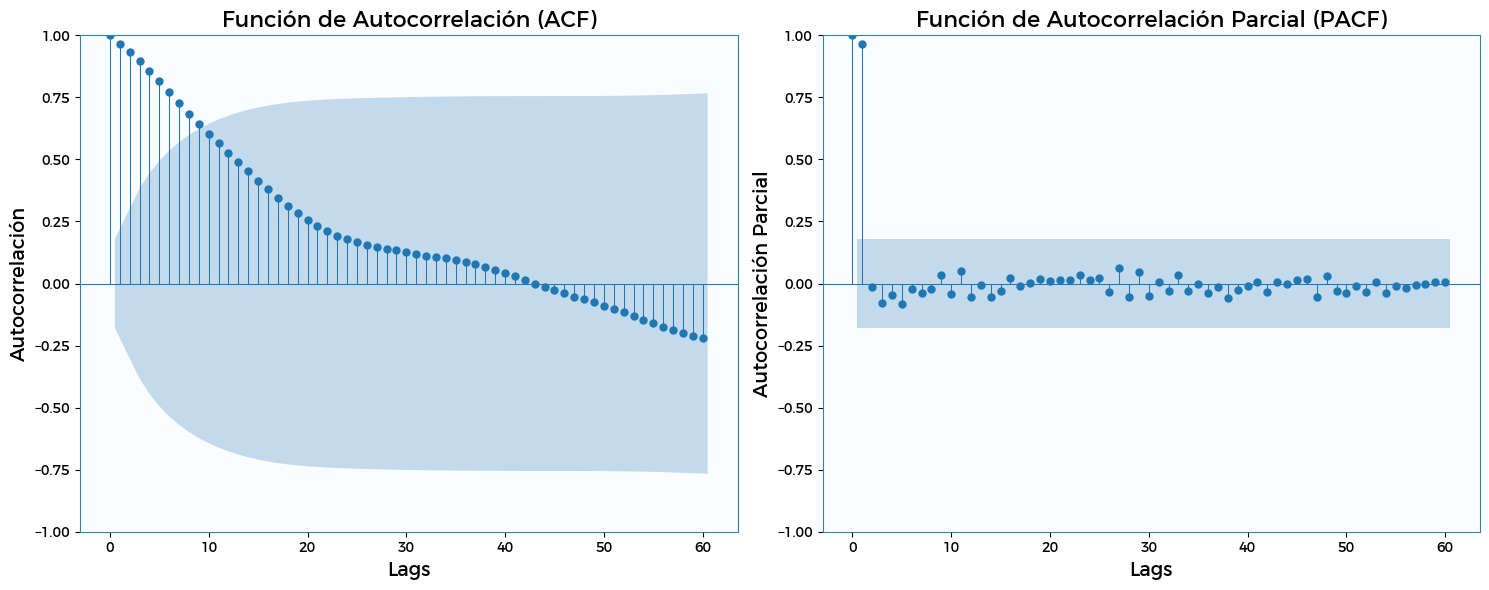

In [4]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ACF subplot
plot_acf(train_to1, lags=60, ax=ax1, title='Función de Autocorrelación (ACF)')
ax1.set_xlabel('Lags')
ax1.set_ylabel('Autocorrelación')

# PACF subplot  
plot_pacf(train_to1, lags=60, ax=ax2, title='Función de Autocorrelación Parcial (PACF)')
ax2.set_xlabel('Lags')
ax2.set_ylabel('Autocorrelación Parcial')

plt.tight_layout()
plt.show()

In [5]:
## information_criterion ('aic', 'aicc', 'bic', 'hqic', 'oob')
# Usar explícitamente la columna producto1 para comparar correctamente con el modelo manual
model = auto_arima(train_to1['producto1'], max_p=10, max_q=10, information_criterion="aic", trace=True)
model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=828.340, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=885.122, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=887.114, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=887.118, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=893.024, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=830.978, Time=0.11 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=831.592, Time=0.07 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=830.337, Time=0.16 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=830.336, Time=0.17 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=873.221, Time=0.08 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=829.166, Time=0.11 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=829.735, Time=0.11 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=832.335, Time=0.27 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=828.706, Time=0.06 sec

Best model:  ARIMA(2,1,2)(0,0,0)[0] intercept


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  121
Model:               SARIMAX(2, 1, 2)   Log Likelihood                -408.170
Date:                Sat, 06 Dec 2025   AIC                            828.340
Time:                        23:24:33   BIC                            845.065
Sample:                             0   HQIC                           835.132
                                - 121                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.9489      0.658     -1.442      0.149      -2.239       0.341
ar.L1          0.3028      0.137      2.204      0.028       0.033       0.572
ar.L2          0.3886      0.145      2.675      0.007       0.104       0.673
ma.L1         -0.4704      0.130     -3.610      0.000      -0.726      -0.215
ma.L2          0.3563      0.129      2.766      0.006       0.104       0.609
sigma2        52.1692      7.635      6.833      0.000      37.206      67.133
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.92
Prob(Q):                              0.99   Prob(JB):                         0.63
Heteroskedasticity (H):               0.89   Skew:                            -0.12
Prob(H) (two-sided):                  0.73   Kurtosis:                         2.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

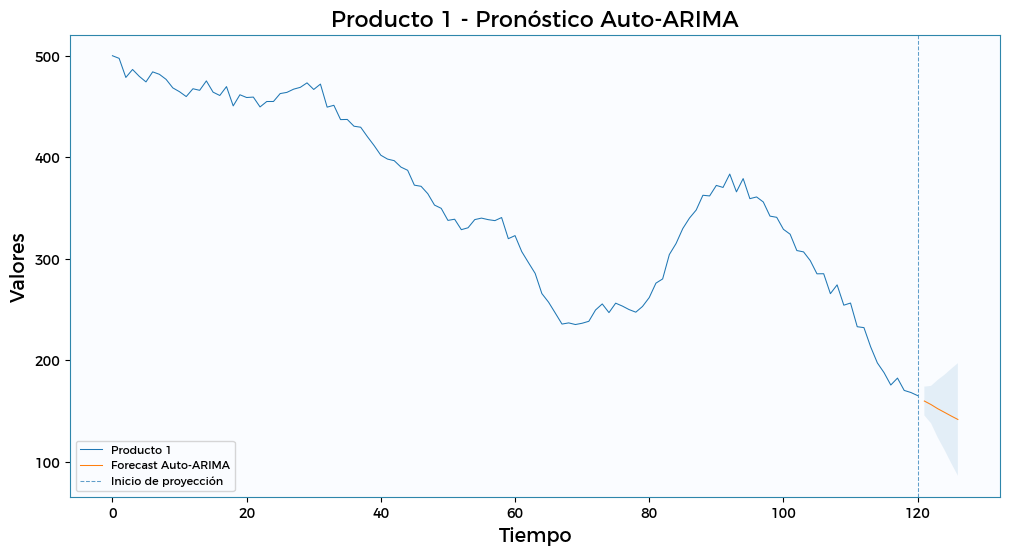

In [6]:
h = 6

y_forec, conf_int = model.predict(h, return_conf_int=True, alpha=0.05)
preds_autoarima = pd.DataFrame(np.column_stack([y_forec, conf_int[:,0], conf_int[:,1]]))
preds_autoarima.columns = ['Point_forecast', 'lower_95', 'upper_95']

fig = plt.figure()
plt.plot(train_to1.index, train_to1['producto1'], label="Producto 1")
plt.plot(y_forec.index, preds_autoarima['Point_forecast'], label="Forecast Auto-ARIMA")
plt.fill_between(y_forec.index, preds_autoarima['lower_95'], preds_autoarima['upper_95'], alpha=0.1)
plt.axvline(train_to1.index[-1], linestyle='--', alpha=0.7, label='Inicio de proyección')
plt.title("Producto 1 - Pronóstico Auto-ARIMA")
plt.xlabel("Tiempo")
plt.ylabel("Valores")
plt.legend(loc="lower left")
plt.show()

In [7]:
# Calcular RMSE del modelo autoarima
print("Datos reales (test):")
print(test_to1["producto1"].values)
print("\nPredicciones autoarima:")
print(preds_autoarima['Point_forecast'].values)

# Calcular RMSE del autoarima
rmse_autoarima = np.sqrt(mean_squared_error(test_to1["producto1"].values, preds_autoarima['Point_forecast'].values))

print(f"\nRMSE del modelo autoarima: {rmse_autoarima:.2f}")

Datos reales (test):
[164.6254717 164.6107711 150.8818393 151.7884696 137.0476394 141.9908727]

Predicciones autoarima:
[159.93683929 156.44295125 152.36190119 148.81955042 145.21215964
 141.79440294]

RMSE del modelo autoarima: 5.27


### 3.2 Modelos ARIMA Manuales y Bootstrap

In [8]:
model = ARIMA(train_to1['producto1'], order=(2,1,2))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              producto1   No. Observations:                  121
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -409.353
Date:                Sat, 06 Dec 2025   AIC                            828.706
Time:                        23:24:33   BIC                            842.644
Sample:                             0   HQIC                           834.366
                                - 121                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3291      0.139      2.361      0.018       0.056       0.602
ar.L2          0.4255      0.139      3.056      0.002       0.153       0.698
ma.L1         -0.4768      0.132     -3.602      0.000      -0.736      -0.217
ma.L2          0.3298      0.126      2.625      0.009       0.084       0.576
sigma2        53.1559      7.585      7.008      0.000      38.290      68.022
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 0.91
Prob(Q):                              0.85   Prob(JB):                         0.63
Heteroskedasticity (H):               0.86   Skew:                            -0.14
Prob(H) (two-sided):                  0.63   Kurtosis:                         2.68
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
h = 6
res = results.resid

my_samples = []
for _ in range(train_to1["producto1"].shape[0]):
    x = np.random.choice(res, size=h, replace=True)
    my_samples.append(x)

q1 = np.quantile(my_samples, 0.025, axis=0)
q2 = np.quantile(my_samples, 0.975, axis=0)

# Usar forecast en lugar de predict
fore = results.forecast(steps=h)

preds_bootstrap = pd.DataFrame(np.column_stack([fore, fore+np.cumsum(q1), fore+np.cumsum(q2)]))
preds_bootstrap.columns = ['Point_forecast', 'lower_95', 'upper_95']

# Generar índices numéricos consecutivos para las proyecciones
start_idx = len(train_to1)
preds_bootstrap.index = range(start_idx, start_idx + h)

preds_bootstrap

,Point_forecast,lower_95,upper_95
121,160.984160,147.087564,174.529081
122,158.303675,130.510484,185.385358
123,155.595756,115.103730,195.610767
124,153.563874,97.380252,209.200159
125,151.742830,79.867612,220.924037
126,150.278847,59.777661,232.294311


In [10]:
# COMPARACIÓN DIRECTA: Predicción simple del modelo ARIMA(2,1,2) manual
# Sin bootstrap, solo la predicción puntual del modelo
h = 6
fore_manual = results.forecast(steps=h)

# Crear DataFrame con predicciones (sin intervalos bootstrap)
preds_manual = pd.DataFrame({
    'Point_forecast': fore_manual
})

# Generar índices numéricos consecutivos
start_idx = len(train_to1)
preds_manual.index = range(start_idx, start_idx + h)

print("Predicciones modelo ARIMA(2,1,2) manual:")
print(preds_manual['Point_forecast'].values)
print("\nDatos reales (test):")
print(test_to1["producto1"].values)

# Calcular RMSE del modelo manual (sin bootstrap)
rmse_manual = np.sqrt(mean_squared_error(test_to1["producto1"].values, preds_manual['Point_forecast'].values))
print(f"\nRMSE del modelo ARIMA(2,1,2) manual: {rmse_manual:.2f}")


Predicciones modelo ARIMA(2,1,2) manual:
[160.98415968 158.30367453 155.59575585 153.56387415 151.7428297
 150.27884685]

Datos reales (test):
[164.6254717 164.6107711 150.8818393 151.7884696 137.0476394 141.9908727]

RMSE del modelo ARIMA(2,1,2) manual: 7.78


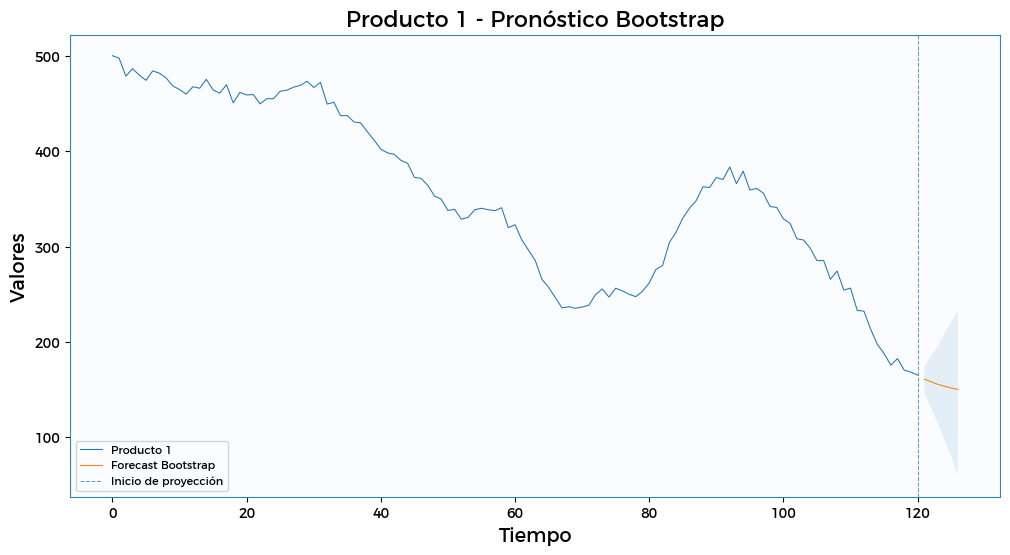

In [11]:
fig = plt.figure()  
plt.plot(range(len(train_to1)), train_to1["producto1"], label="Producto 1")
plt.plot(preds_bootstrap.index, preds_bootstrap['Point_forecast'], label="Forecast Bootstrap")
plt.axvline(len(train_to1)-1, linestyle='--', alpha=0.7, label='Inicio de proyección')
plt.fill_between(preds_bootstrap.index, preds_bootstrap['lower_95'], preds_bootstrap['upper_95'], alpha=0.1)
plt.title("Producto 1 - Pronóstico Bootstrap")
plt.xlabel("Tiempo")
plt.ylabel("Valores")
plt.legend(loc="lower left")
plt.show()

In [12]:
# Calcular RMSE comparando predicciones bootstrap con datos de prueba
print("Datos reales (test):")
print(test_to1["producto1"].values)
print("\nPredicciones bootstrap:")
print(preds_bootstrap['Point_forecast'].values)

# Calcular RMSE
from sklearn.metrics import mean_squared_error
rmse_bootstrap = np.sqrt(mean_squared_error(test_to1["producto1"].values, preds_bootstrap['Point_forecast'].values))

print(f"\nRMSE del modelo bootstrap: {rmse_bootstrap:.2f}")

Datos reales (test):
[164.6254717 164.6107711 150.8818393 151.7884696 137.0476394 141.9908727]

Predicciones bootstrap:
[160.98415968 158.30367453 155.59575585 153.56387415 151.7428297
 150.27884685]

RMSE del modelo bootstrap: 7.78


In [13]:
# Comparación de modelos
print("="*60)
print("COMPARACIÓN DE MODELOS")
print("="*60)

# Del modelo autoarima (primera predicción)
print(f"MODELO AUTOARIMA:")
print(f"  RMSE: {rmse_autoarima:.2f}")
print()

# Del modelo bootstrap 
print(f"MODELO BOOTSTRAP ARIMA(2,1,2):")
print(f"  RMSE: {rmse_bootstrap:.2f}")

COMPARACIÓN DE MODELOS
MODELO AUTOARIMA:
  RMSE: 5.27

MODELO BOOTSTRAP ARIMA(2,1,2):
  RMSE: 7.78


## 6. OPTIMIZACIÓN BAYESIANA CON OPTUNA

In [14]:
def evaluar_expanding_forecast(serie, order, window=12, step_size=1, horizon=1, metric='rmse'):
    """
    Simula pronósticos autoregresivos en tiempo real con ventana expandida desde el inicio.

    Parámetros:
        serie     : serie temporal (pd.Series o array-like)
        order     : tupla ARIMA (p,d,q)
        window    : cantidad de pronósticos (desde el final hacia atrás)
        step_size : cada cuántos puntos se hace un pronóstico
        horizon   : cuántos pasos adelante predices en cada punto
        metric    : 'rmse' o 'mae'

    Retorna:
        Error promedio global (RMSE o MAE) entre todos los valores predichos vs observados.
    """

    # Asegurar tipo y limpiar NaN de la serie
    serie = pd.Series(serie).astype(float).dropna()

    n = len(serie)
    predichos = []
    observados = []

    # índices donde termina el conjunto de entrenamiento
    puntos_finales = list(range(n - window * step_size, n - horizon + 1, step_size))

    for end_train in puntos_finales:
        train = serie.iloc[:end_train]
        test = serie.iloc[end_train:end_train + horizon]

        if len(test) < horizon:
            continue

        # Si el test ya tiene NaN, lo ignoramos
        if test.isna().any():
            continue

        try:
            model = ARIMA(
                train,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit()

            pred = model.forecast(steps=horizon)

        except Exception:
            # Si falla el ajuste o el forecast, pasamos a la siguiente ventana
            continue

        # Convertir a Series y filtrar NaN en predicciones
        pred = pd.Series(pred).astype(float)

        # Máscara conjunta para asegurar que ni observados ni predichos tengan NaN
        mask = (~pred.isna()) & (~test.isna())

        if mask.sum() == 0:
            continue

        predichos.extend(pred[mask].tolist())
        observados.extend(test[mask].tolist())

    if len(predichos) == 0:
        return np.inf

    predichos = np.array(predichos, dtype=float)
    observados = np.array(observados, dtype=float)

    mask_finite = (
        np.isfinite(predichos) &
        np.isfinite(observados)
    )

    if mask_finite.sum() == 0:
        return np.inf

    predichos = predichos[mask_finite]
    observados = observados[mask_finite]

    # Cálculo de la métrica
    if metric == 'rmse':
        return np.sqrt(mean_squared_error(observados, predichos))
    elif metric == 'mae':
        return np.mean(np.abs(observados - predichos))
    else:
        raise ValueError("Metric must be 'rmse' or 'mae'")


In [ ]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

def objective(trial):
    p = trial.suggest_int("p", 2, 8)
    d = trial.suggest_int("d", 2, 2)
    q = trial.suggest_int("q", 1, 10)
    window = trial.suggest_int("window", 6, 20)

    order = (p, d, q)
    return evaluar_expanding_forecast(train_to1["producto1"], order, window=window, step_size=1, horizon=1)


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

print("\nMejores hiperparámetros:")
print(f"  p = {study.best_params['p']}")
print(f"  d = {study.best_params['d']}")
print(f"  q = {study.best_params['q']}")
print(f"  window = {study.best_params['window']}")
print(f"  RMSE = {study.best_value:.4f}")

[I 2025-12-06 23:24:33,984] A new study created in memory with name: no-name-c868de42-883c-4e1b-9faf-fd7b3bb7b24f
[I 2025-12-06 23:24:41,575] Trial 0 finished with value: 7.466819134427095 and parameters: {'p': 5, 'd': 2, 'q': 7, 'window': 16}. Best is trial 0 with value: 7.466819134427095.
[I 2025-12-06 23:24:47,725] Trial 1 finished with value: 8.052593374711433 and parameters: {'p': 3, 'd': 2, 'q': 6, 'window': 18}. Best is trial 0 with value: 7.466819134427095.
[I 2025-12-06 23:24:53,750] Trial 2 finished with value: 8.241554551115543 and parameters: {'p': 4, 'd': 2, 'q': 8, 'window': 12}. Best is trial 0 with value: 7.466819134427095.
[I 2025-12-06 23:25:05,895] Trial 3 finished with value: 7.223955654795558 and parameters: {'p': 8, 'd': 2, 'q': 10, 'window': 18}. Best is trial 3 with value: 7.223955654795558.
[I 2025-12-06 23:25:14,491] Trial 4 finished with value: 6.92257545091797 and parameters: {'p': 6, 'd': 2, 'q': 6, 'window': 20}. Best is trial 4 with value: 6.9225754509179

In [ ]:
# Visualización de resultados de optimización
from optuna.visualization import (plot_optimization_history, plot_param_importances, 
                                   plot_slice, plot_contour, plot_parallel_coordinate, plot_edf)

# 1. Historial de convergencia
fig1 = plot_optimization_history(study)
fig1.update_layout(title="Historial de Convergencia")
fig1.show()

# 2. Importancia de parámetros
fig2 = plot_param_importances(study)
fig2.update_layout(title="Importancia de Hiperparámetros")
fig2.show()

# 3. Efecto individual de cada parámetro
fig3 = plot_slice(study)
fig3.update_layout(title="Efecto Individual de Parámetros")
fig3.show()

# 4. Relación entre pares de parámetros
fig4 = plot_contour(study, params=["p", "q"])
fig4.update_layout(title="Interacción entre p y q")
fig4.show()

# 5. Coordenadas paralelas
fig5 = plot_parallel_coordinate(study)
fig5.update_layout(title="Coordenadas Paralelas de Hiperparámetros")
fig5.show()

# 6. Distribución empírica acumulada
fig6 = plot_edf(study)
fig6.update_layout(title="Distribución Empírica (EDF) de RMSE")
fig6.show()

## 4. MODELO ÓPTIMO CON DATASET COMPLETO

In [ ]:
# Ajustar modelo con los parámetros óptimos encontrados por Optuna
best_order = (study.best_params['p'], study.best_params['d'], study.best_params['q'])

print(f"Ajustando modelo ARIMA{best_order} con dataset completo...")
model_optimo = ARIMA(data['producto1'], order=best_order)
results_optimo = model_optimo.fit()

print(f"\nModelo óptimo ajustado: ARIMA{best_order}")
results_optimo.summary()

Ajustando modelo ARIMA(6, 2, 7) con dataset completo...

Modelo óptimo ajustado: ARIMA(6, 2, 7)

Modelo óptimo ajustado: ARIMA(6, 2, 7)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              producto1   No. Observations:                  127
Model:                 ARIMA(6, 2, 7)   Log Likelihood                -416.250
Date:               sáb, 06 dic. 2025   AIC                            860.500
Time:                        21:50:34   BIC                            900.096
Sample:                             0   HQIC                           876.586
                                - 127                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1112      0.462     -2.403      0.016      -2.018      -0.205
ar.L2         -0.2194      0.455     -0.483      0.629      -1.110       0.672
ar.L3         -0.1754      0.372     -0.472      0.637      -0.905       0.554
ar.L4          0.0637      0.240      0.265      0.791      -0.407       0.535
ar.L5          0.7385      0.214      3.453      0.001       0.319       1.158
ar.L6          0.2892      0.248      1.167      0.243      -0.196       0.775
ma.L1          0.0220      1.460      0.015      0.988      -2.840       2.884
ma.L2         -0.2059      2.786     -0.074      0.941      -5.666       5.254
ma.L3          0.4208      2.610      0.161      0.872      -4.695       5.536
ma.L4         -0.4600      2.883     -0.160      0.873      -6.111       5.191
ma.L5         -0.8307      2.267     -0.366      0.714      -5.275       3.613
ma.L6          0.2098      0.771      0.272      0.786      -1.301       1.720
ma.L7         -0.1501      0.660     -0.228      0.820      -1.443       1.143
sigma2        42.0525    146.139      0.288      0.774    -244.375     328.480
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.34
Prob(Q):                              0.94   Prob(JB):                         0.51
Heteroskedasticity (H):               0.66   Skew:                            -0.25
Prob(H) (two-sided):                  0.18   Kurtosis:                         3.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

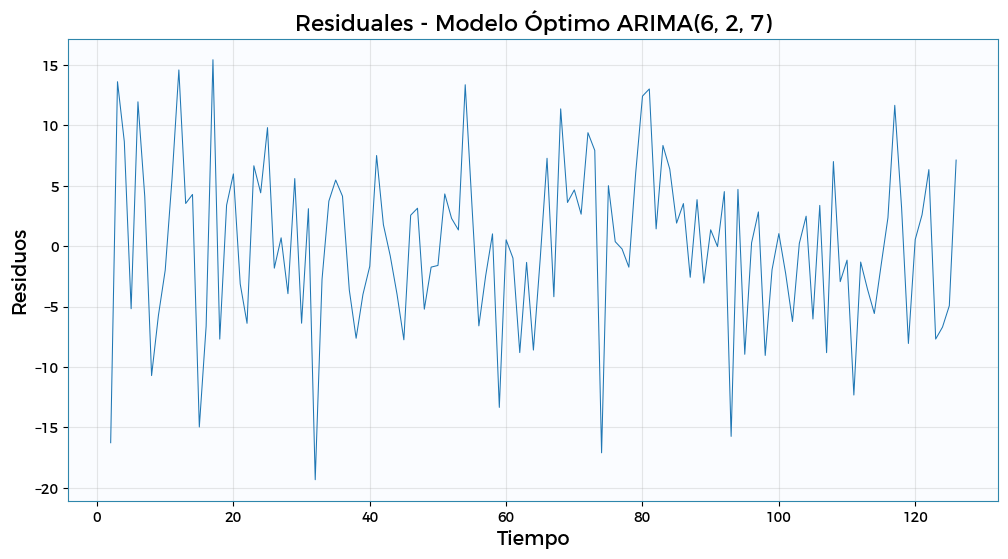

In [ ]:
residuos_optimo = results_optimo.resid[study.best_params['d']:]

fig = plt.figure()
plt.plot(residuos_optimo)
plt.title(f"Residuales - Modelo Óptimo ARIMA{best_order}")
plt.xlabel("Tiempo")
plt.ylabel("Residuos")
plt.grid(True, alpha=0.3)
plt.show()

## 5. VALIDACIÓN DE SUPUESTOS DEL MODELO ÓPTIMO

=== VALIDACIÓN DE SUPUESTOS - MODELO ARIMA(6, 2, 7) ===

=== AUTOCORRELACIÓN ===
Test Ljung-Box: p-valor = 0.911032
✓ No hay autocorrelación


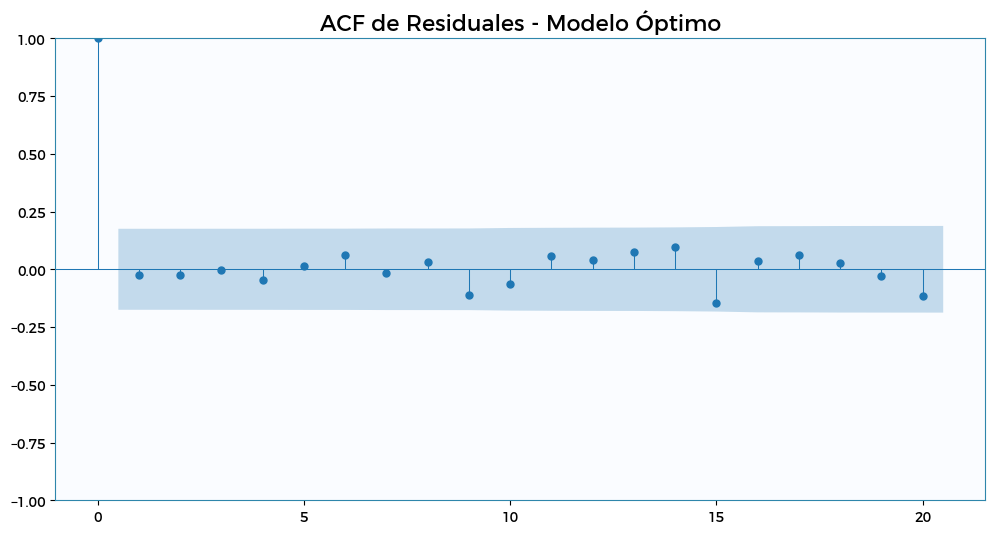

In [ ]:
# 1. SUPUESTO: NO AUTOCORRELACIÓN
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import pandas as pd

print(f"=== VALIDACIÓN DE SUPUESTOS - MODELO ARIMA{best_order} ===\n")
print("=== AUTOCORRELACIÓN ===")
ljung_autocorr_opt = acorr_ljungbox(residuos_optimo, lags=24)['lb_pvalue'].iloc[-1]
print(f"Test Ljung-Box: p-valor = {ljung_autocorr_opt:.6f}")

if ljung_autocorr_opt > 0.05:
    print("✓ No hay autocorrelación")
else:
    print("✗ HAY autocorrelación")
    
# Gráfico ACF
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuos_optimo, lags=20, title="ACF de Residuales - Modelo Óptimo")
plt.show()

=== NORMALIDAD ===
Test Shapiro-Wilk: p-valor = 0.376675
Test Jarque-Bera: p-valor = 0.475748
✓ Los residuales son normales


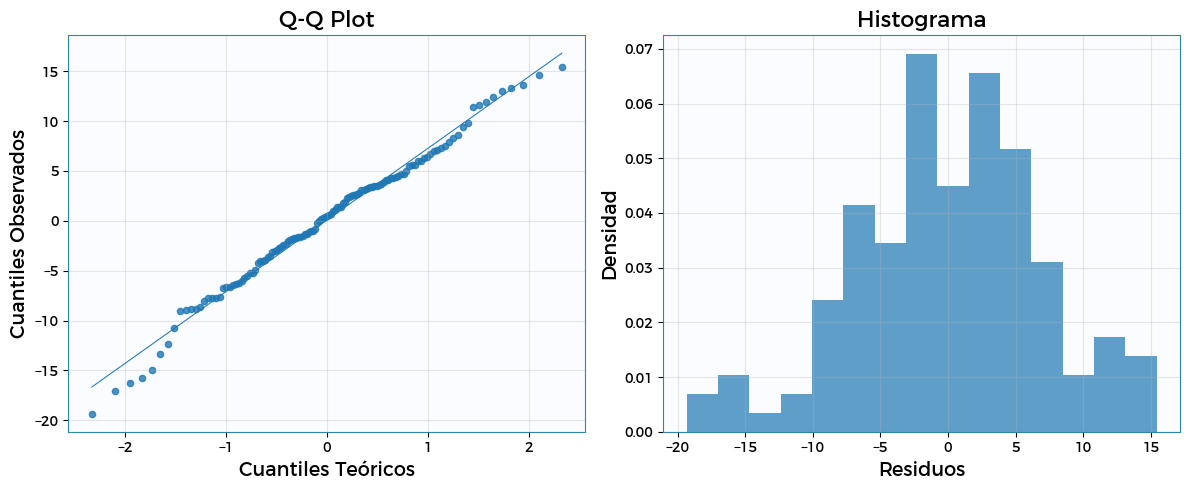

In [ ]:
# 2. SUPUESTO: NORMALIDAD
print("=== NORMALIDAD ===")

# Shapiro-Wilk
shapiro_pvalue_opt = stats.shapiro(residuos_optimo)[1]
print(f"Test Shapiro-Wilk: p-valor = {shapiro_pvalue_opt:.6f}")

# Jarque-Bera
jb_pvalue_opt = stats.jarque_bera(residuos_optimo)[1]
print(f"Test Jarque-Bera: p-valor = {jb_pvalue_opt:.6f}")

if shapiro_pvalue_opt > 0.05 and jb_pvalue_opt > 0.05:
    print("✓ Los residuales son normales")
else:
    print("✗ Los residuales NO son normales")

# Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q Plot
sorted_residuos_opt = np.sort(residuos_optimo)
n_opt = len(sorted_residuos_opt)
theoretical_quantiles_opt = stats.norm.ppf(np.linspace(0.01, 0.99, n_opt))

ax1.scatter(theoretical_quantiles_opt, sorted_residuos_opt, alpha=0.8, s=20)
slope_opt, intercept_opt = np.polyfit(theoretical_quantiles_opt, sorted_residuos_opt, 1)
ax1.plot(theoretical_quantiles_opt, slope_opt * theoretical_quantiles_opt + intercept_opt)
ax1.set_xlabel("Cuantiles Teóricos")
ax1.set_ylabel("Cuantiles Observados")
ax1.set_title("Q-Q Plot")
ax1.grid(True, alpha=0.3)

# Histograma
ax2.hist(residuos_optimo, bins=15, density=True, alpha=0.7)
ax2.set_title("Histograma")
ax2.set_xlabel("Residuos")
ax2.set_ylabel("Densidad")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== HOMOSCEDASTICIDAD ===
Test Ljung-Box (res²): p-valor = 0.898139
Test Breusch-Pagan: p-valor = 0.039741
✗ Varianza NO constante (heteroscedasticidad)


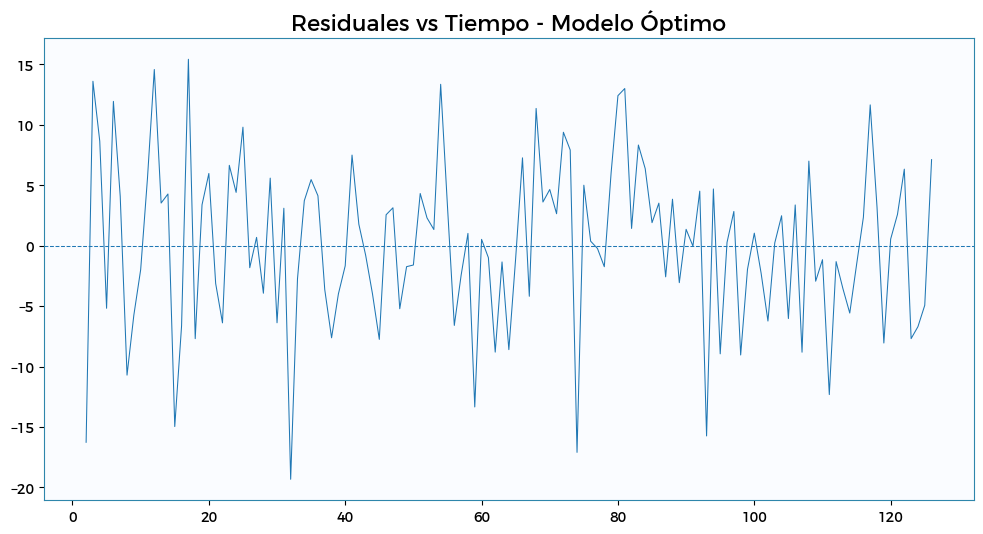

In [ ]:
# 3. SUPUESTO: HOMOSCEDASTICIDAD
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

print("=== HOMOSCEDASTICIDAD ===")

# Ljung-Box en residuos²
ljung_hetero_opt = acorr_ljungbox(residuos_optimo**2, lags=10)['lb_pvalue'].iloc[-1]
print(f"Test Ljung-Box (res²): p-valor = {ljung_hetero_opt:.6f}")

# Breusch-Pagan
tiempo_opt = np.arange(len(residuos_optimo)).reshape(-1, 1)
tiempo_const_opt = sm.add_constant(tiempo_opt)
bp_pvalue_opt = het_breuschpagan(residuos_optimo, tiempo_const_opt)[1]
print(f"Test Breusch-Pagan: p-valor = {bp_pvalue_opt:.6f}")

if ljung_hetero_opt > 0.05 and bp_pvalue_opt > 0.05:
    print("✓ Varianza constante (homoscedasticidad)")
else:
    print("✗ Varianza NO constante (heteroscedasticidad)")

# Gráfico
plt.figure()
plt.plot(residuos_optimo)
plt.axhline(y=0, linestyle='--')
plt.title("Residuales vs Tiempo - Modelo Óptimo")
plt.show()

In [ ]:
# RESUMEN: Tabla de resultados
resultados_optimo = pd.DataFrame({
    'Supuesto': ['No Autocorrelación', 'Normalidad', 'Normalidad', 'Homoscedasticidad', 'Homoscedasticidad'],
    'Prueba': ['Ljung-Box', 'Shapiro-Wilk', 'Jarque-Bera', 'Ljung-Box (res²)', 'Breusch-Pagan'],
    'P-valor': [ljung_autocorr_opt, shapiro_pvalue_opt, jb_pvalue_opt, ljung_hetero_opt, bp_pvalue_opt],
    'Cumple': ['✓' if ljung_autocorr_opt > 0.05 else '✗',
               '✓' if shapiro_pvalue_opt > 0.05 else '✗',
               '✓' if jb_pvalue_opt > 0.05 else '✗',
               '✓' if ljung_hetero_opt > 0.05 else '✗',
               '✓' if bp_pvalue_opt > 0.05 else '✗']
})

print(f"\nTABLA RESUMEN DE SUPUESTOS - MODELO ARIMA{best_order}:")
print(resultados_optimo.to_string(index=False))


TABLA RESUMEN DE SUPUESTOS - MODELO ARIMA(6, 2, 7):
          Supuesto           Prueba  P-valor Cumple
No Autocorrelación        Ljung-Box 0.911032      ✓
        Normalidad     Shapiro-Wilk 0.376675      ✓
        Normalidad      Jarque-Bera 0.475748      ✓
 Homoscedasticidad Ljung-Box (res²) 0.898139      ✓
 Homoscedasticidad    Breusch-Pagan 0.039741      ✗


## 6. VALIDACIÓN CON VENTANA MÓVIL - MODELO ÓPTIMO

### Ventana Fija vs Ventana Móvil

**Ventana Fija:**
- Entrena con todos los datos de entrenamiento
- Predice todos los datos de prueba a la vez

**Ventana Móvil:**
- Usa una ventana fija que se desplaza
- En cada paso: entrena con los últimos N datos y predice 1 paso adelante
- Simula mejor la predicción en tiempo real

VALIDACIÓN CON VENTANA MÓVIL - MODELO ARIMA(6, 2, 7)

RESULTADOS:
  RMSE Auto-ARIMA (Ventana Fija):      5.2662
  RMSE ARIMA Manual (Ventana Fija):    7.7787
  RMSE Ventana Móvil (Óptima):         9.1062
  Ventana utilizada: 20

RESULTADOS:
  RMSE Auto-ARIMA (Ventana Fija):      5.2662
  RMSE ARIMA Manual (Ventana Fija):    7.7787
  RMSE Ventana Móvil (Óptima):         9.1062
  Ventana utilizada: 20


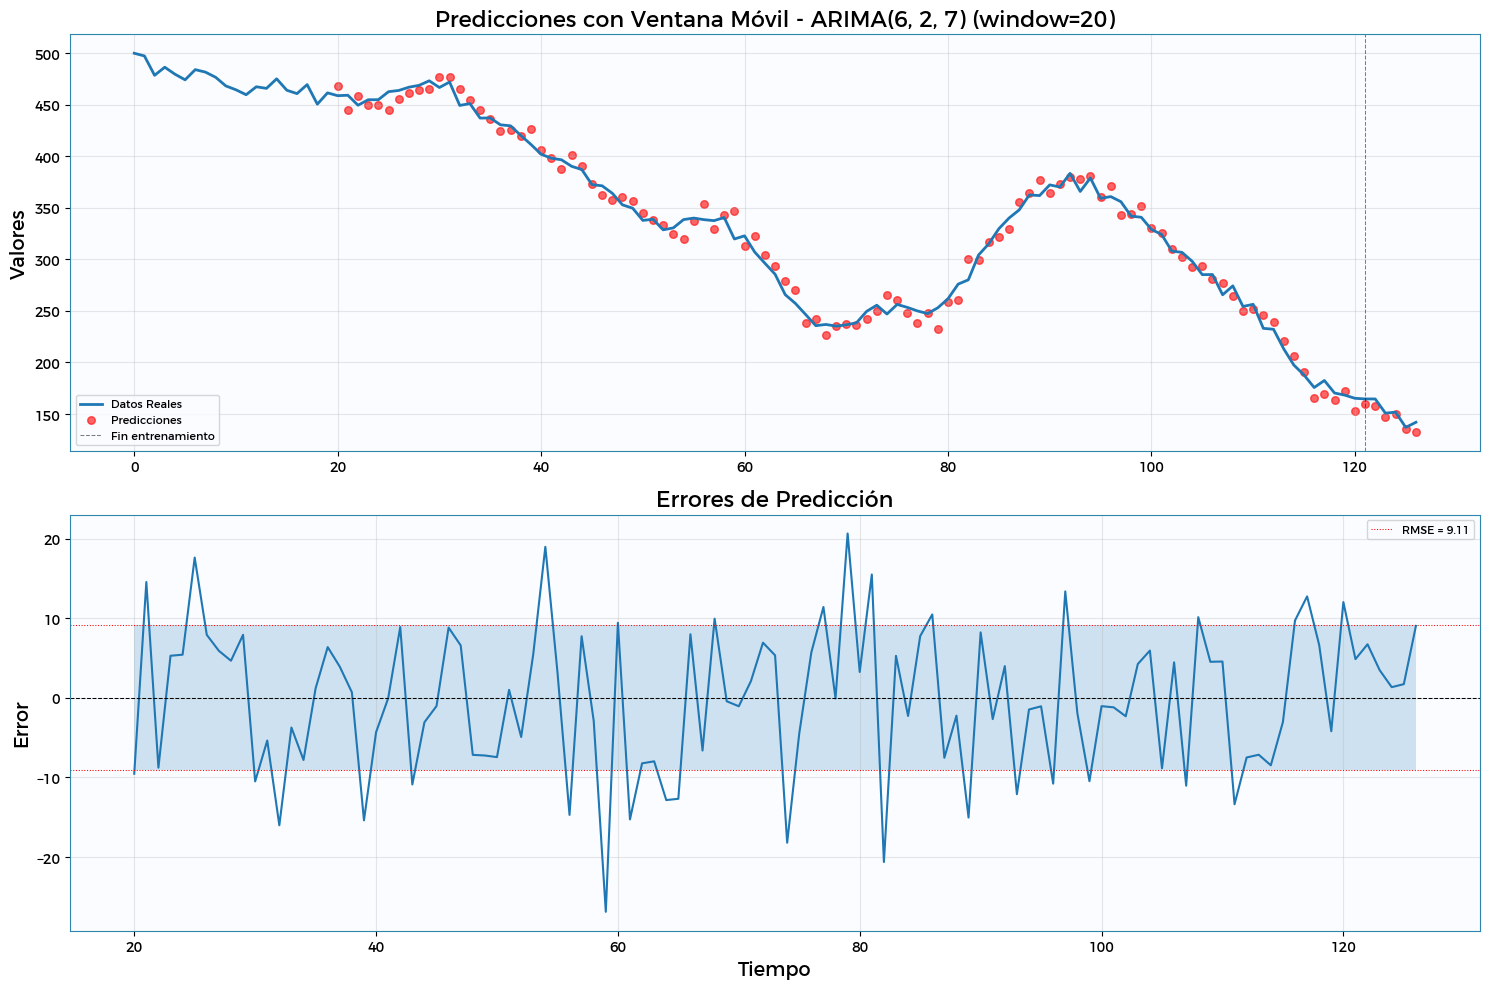

In [ ]:
# Validación con ventana móvil usando parámetros óptimos
print(f"VALIDACIÓN CON VENTANA MÓVIL - MODELO ARIMA{best_order}")
print("="*60)

# Configuración con la ventana óptima de Optuna
window_size_opt = study.best_params['window']
datos_completos = pd.concat([train_to1['producto1'], test_to1['producto1']])

# Almacenar predicciones
predicciones_rolling_opt = []
valores_reales_rolling_opt = []
indices_prediccion_opt = []

# Iterar con ventana móvil
for i in range(len(datos_completos) - window_size_opt):
    train_window_opt = datos_completos.iloc[i:i+window_size_opt]
    valor_real_opt = datos_completos.iloc[i+window_size_opt]
    
    try:
        model_rolling_opt = ARIMA(train_window_opt, order=best_order)
        results_rolling_opt = model_rolling_opt.fit()
        pred_opt = results_rolling_opt.forecast(steps=1).iloc[0]
        
        predicciones_rolling_opt.append(pred_opt)
        valores_reales_rolling_opt.append(valor_real_opt)
        indices_prediccion_opt.append(i + window_size_opt)
    except:
        continue

# Convertir a arrays
predicciones_rolling_opt = np.array(predicciones_rolling_opt)
valores_reales_rolling_opt = np.array(valores_reales_rolling_opt)

# Calcular RMSE
rmse_rolling_opt = np.sqrt(mean_squared_error(valores_reales_rolling_opt, predicciones_rolling_opt))

print(f"\nRESULTADOS:")
print(f"  RMSE Auto-ARIMA (Ventana Fija):      {rmse_autoarima:.4f}")
print(f"  RMSE ARIMA Manual (Ventana Fija):    {rmse_manual:.4f}")
print(f"  RMSE Ventana Móvil (Óptima):         {rmse_rolling_opt:.4f}")
print(f"  Ventana utilizada: {window_size_opt}")
print("="*60)

# Gráficos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Serie completa con predicciones
ax1.plot(range(len(datos_completos)), datos_completos.values, 
         label='Datos Reales', linewidth=2)
ax1.scatter(indices_prediccion_opt, predicciones_rolling_opt, 
           label='Predicciones', color='red', s=30, alpha=0.6)
ax1.axvline(x=len(train_to1), linestyle='--', color='black', 
           alpha=0.5, label='Fin entrenamiento')
ax1.set_title(f'Predicciones con Ventana Móvil - ARIMA{best_order} (window={window_size_opt})')
ax1.set_ylabel('Valores')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Errores
errores_rolling_opt = valores_reales_rolling_opt - predicciones_rolling_opt
ax2.plot(indices_prediccion_opt, errores_rolling_opt, linewidth=1.5)
ax2.axhline(y=0, color='black', linestyle='--')
ax2.axhline(y=rmse_rolling_opt, color='red', linestyle=':', label=f'RMSE = {rmse_rolling_opt:.2f}')
ax2.axhline(y=-rmse_rolling_opt, color='red', linestyle=':')
ax2.fill_between(indices_prediccion_opt, -rmse_rolling_opt, rmse_rolling_opt, alpha=0.2)
ax2.set_title('Errores de Predicción')
ax2.set_xlabel('Tiempo')
ax2.set_ylabel('Error')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. ANÁLISIS ARIMA - PRODUCTO 2

### 8.1 Análisis de Autocorrelación

In [ ]:
acf(train_to2,100)

array([ 1.        ,  0.97501029,  0.95383042,  0.92680303,  0.90367871,
        0.87525207,  0.85035962,  0.82079481,  0.79491087,  0.76655777,
        0.74124074,  0.7130484 ,  0.68666159,  0.6572822 ,  0.62988108,
        0.60009499,  0.57384352,  0.54525581,  0.52050914,  0.49322915,
        0.46792792,  0.44220821,  0.41572845,  0.38963533,  0.36325207,
        0.33587029,  0.30959011,  0.28272008,  0.25680931,  0.2316067 ,
        0.20636115,  0.18080701,  0.15586666,  0.13355179,  0.10954124,
        0.0890734 ,  0.06723547,  0.04976181,  0.0301335 ,  0.01306589,
       -0.00637286, -0.02368279, -0.04406875, -0.06280323, -0.08384049,
       -0.10320539, -0.12226462, -0.13915786, -0.15593552, -0.17117033,
       -0.18511523, -0.19912765, -0.21129704, -0.22347262, -0.23423012,
       -0.2484517 , -0.26080126, -0.27528438, -0.2865198 , -0.29914432,
       -0.30979469, -0.32055184, -0.3292852 , -0.33828521, -0.34513324,
       -0.35281744, -0.35765734, -0.36315998, -0.36592318, -0.37

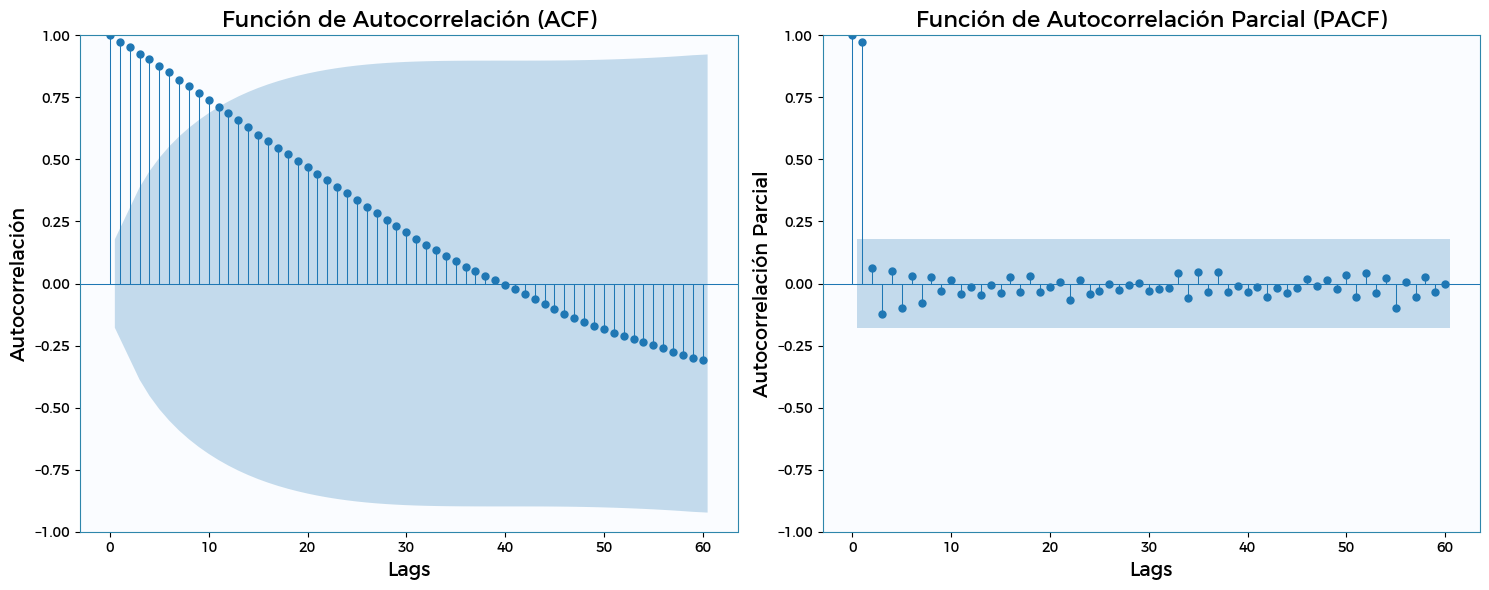

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ACF subplot
plot_acf(train_to2, lags=60, ax=ax1, title='Función de Autocorrelación (ACF)')
ax1.set_xlabel('Lags')
ax1.set_ylabel('Autocorrelación')

# PACF subplot  
plot_pacf(train_to2, lags=60, ax=ax2, title='Función de Autocorrelación Parcial (PACF)')
ax2.set_xlabel('Lags')
ax2.set_ylabel('Autocorrelación Parcial')

plt.tight_layout()
plt.show()

In [ ]:
## information_criterion ('aic', 'aicc', 'bic', 'hqic', 'oob')
# Usar explícitamente la columna producto2 para comparar correctamente con el modelo manual
model_p2 = auto_arima(train_to2['producto2'], max_p=10, max_q=10, information_criterion="aic", trace=True)
model_p2.summary()

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0]             : AIC=899.154, Time=0.12 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=1115.687, Time=0.00 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=894.122, Time=0.02 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=996.165, Time=0.03 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=895.765, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=895.717, Time=0.05 sec
 ARIMA(2,2,1)(0,0,0)[0]             : AIC=889.633, Time=0.07 sec
 ARIMA(3,2,1)(0,0,0)[0]             : AIC=891.332, Time=0.10 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=895.717, Time=0.05 sec
 ARIMA(2,2,1)(0,0,0)[0]             : AIC=889.633, Time=0.07 sec
 ARIMA(3,2,1)(0,0,0)[0]             : AIC=891.332, Time=0.10 sec
 ARIMA(1,2,2)(0,0,0)[0]             : AIC=897.176, Time=0.04 sec
 ARIMA(3,2,0)(0,0,0)[0]             : AIC=897.367, Time=0.03 sec
 ARIMA(1,2,2)(0,0,0)[0]             : AIC=897.176, Time=0.04 sec
 ARIMA(3,2,0)(0,0,0)[0]             : AIC=897.

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  121
Model:               SARIMAX(2, 2, 1)   Log Likelihood                -440.817
Date:               sáb, 06 dic. 2025   AIC                            889.633
Time:                        21:51:30   BIC                            900.749
Sample:                             0   HQIC                           894.147
                                - 121                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1120      0.099     -1.127      0.260      -0.307       0.083
ar.L2          0.7195      0.104      6.895      0.000       0.515       0.924
ma.L1         -0.9666      0.052    -18.473      0.000      -1.069      -0.864
sigma2        94.4580     12.156      7.770      0.000      70.632     118.284
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 0.61
Prob(Q):                              0.87   Prob(JB):                         0.74
Heteroskedasticity (H):               1.00   Skew:                            -0.16
Prob(H) (two-sided):                  0.99   Kurtosis:                         3.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

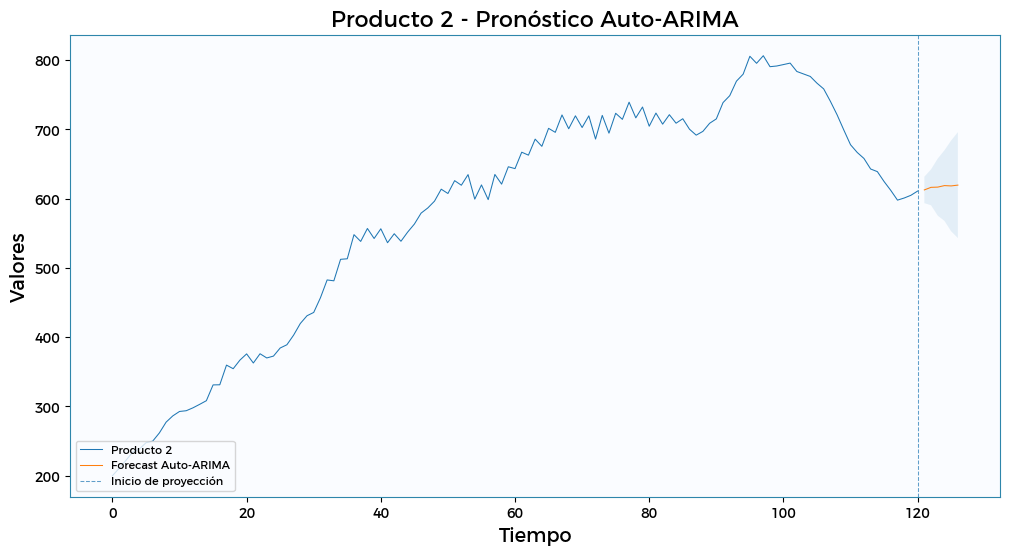

In [ ]:
h = 6

y_forec_p2, conf_int_p2 = model_p2.predict(h, return_conf_int=True, alpha=0.05)
preds_autoarima_p2 = pd.DataFrame(np.column_stack([y_forec_p2, conf_int_p2[:,0], conf_int_p2[:,1]]))
preds_autoarima_p2.columns = ['Point_forecast', 'lower_95', 'upper_95']

fig = plt.figure()
plt.plot(train_to2.index, train_to2['producto2'], label="Producto 2")
plt.plot(y_forec_p2.index, preds_autoarima_p2['Point_forecast'], label="Forecast Auto-ARIMA")
plt.fill_between(y_forec_p2.index, preds_autoarima_p2['lower_95'], preds_autoarima_p2['upper_95'], alpha=0.1)
plt.axvline(train_to2.index[-1], linestyle='--', alpha=0.7, label='Inicio de proyección')
plt.title("Producto 2 - Pronóstico Auto-ARIMA")
plt.xlabel("Tiempo")
plt.ylabel("Valores")
plt.legend(loc="lower left")
plt.show()

In [ ]:
# Calcular RMSE del modelo autoarima
print("Datos reales (test):")
print(test_to2["producto2"].values)
print("\nPredicciones autoarima:")
print(preds_autoarima_p2['Point_forecast'].values)

# Calcular RMSE del autoarima
rmse_autoarima_p2 = np.sqrt(mean_squared_error(test_to2["producto2"].values, preds_autoarima_p2['Point_forecast'].values))

print(f"\nRMSE del modelo autoarima: {rmse_autoarima_p2:.2f}")

Datos reales (test):
[624.5021022 629.2930339 637.0994671 653.1552818 672.5283447 676.0580921]

Predicciones autoarima:
[612.67675672 616.40239515 616.73290048 618.91563774 618.44826241
 619.61023494]

RMSE del modelo autoarima: 36.52


### 8.2 Modelos ARIMA Manuales y Bootstrap

In [ ]:
model_p2 = ARIMA(train_to2['producto2'], order=(2,2,1))
results_p2 = model_p2.fit()
results_p2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              producto2   No. Observations:                  121
Model:                 ARIMA(2, 2, 1)   Log Likelihood                -440.817
Date:               sáb, 06 dic. 2025   AIC                            889.633
Time:                        21:51:30   BIC                            900.749
Sample:                             0   HQIC                           894.147
                                - 121                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1120      0.099     -1.127      0.260      -0.307       0.083
ar.L2          0.7195      0.104      6.895      0.000       0.515       0.924
ma.L1         -0.9666      0.052    -18.473      0.000      -1.069      -0.864
sigma2        94.4580     12.156      7.770      0.000      70.632     118.284
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 0.61
Prob(Q):                              0.87   Prob(JB):                         0.74
Heteroskedasticity (H):               1.00   Skew:                            -0.16
Prob(H) (two-sided):                  0.99   Kurtosis:                         3.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
h = 6
res_p2 = results_p2.resid

my_samples_p2 = []
for _ in range(train_to2["producto2"].shape[0]):
    x = np.random.choice(res_p2, size=h, replace=True)
    my_samples_p2.append(x)

q1_p2 = np.quantile(my_samples_p2, 0.025, axis=0)
q2_p2 = np.quantile(my_samples_p2, 0.975, axis=0)

# Usar forecast en lugar de predict
fore_p2 = results_p2.forecast(steps=h)

preds_bootstrap_p2 = pd.DataFrame(np.column_stack([fore_p2, fore_p2+np.cumsum(q1_p2), fore_p2+np.cumsum(q2_p2)]))
preds_bootstrap_p2.columns = ['Point_forecast', 'lower_95', 'upper_95']

# Generar índices numéricos consecutivos para las proyecciones
start_idx_p2 = len(train_to2)
preds_bootstrap_p2.index = range(start_idx_p2, start_idx_p2 + h)

preds_bootstrap_p2

,Point_forecast,lower_95,upper_95
121,612.676757,580.729186,630.842351
122,616.402395,568.823057,652.054851
123,616.732900,551.811144,670.550951
124,618.915638,529.216295,690.899282
125,618.448262,511.406501,707.918769
126,619.610235,490.813477,725.846370


In [ ]:
# COMPARACIÓN DIRECTA: Predicción simple del modelo ARIMA(2,1,2) manual
# Sin bootstrap, solo la predicción puntual del modelo
h = 6
fore_manual_p2 = results_p2.forecast(steps=h)

# Crear DataFrame con predicciones (sin intervalos bootstrap)
preds_manual_p2 = pd.DataFrame({
    'Point_forecast': fore_manual_p2
})

# Generar índices numéricos consecutivos
start_idx_p2 = len(train_to2)
preds_manual_p2.index = range(start_idx_p2, start_idx_p2 + h)

print("Predicciones modelo ARIMA(2,2,1) manual:")
print(preds_manual_p2['Point_forecast'].values)
print("\nDatos reales (test):")
print(test_to2["producto2"].values)

# Calcular RMSE del modelo manual (sin bootstrap)
rmse_manual_p2 = np.sqrt(mean_squared_error(test_to2["producto2"].values, preds_manual_p2['Point_forecast'].values))
print(f"\nRMSE del modelo ARIMA(2,2,1) manual: {rmse_manual_p2:.2f}")


Predicciones modelo ARIMA(2,2,1) manual:
[612.67675672 616.40239515 616.73290048 618.91563774 618.44826241
 619.61023494]

Datos reales (test):
[624.5021022 629.2930339 637.0994671 653.1552818 672.5283447 676.0580921]

RMSE del modelo ARIMA(2,2,1) manual: 36.52


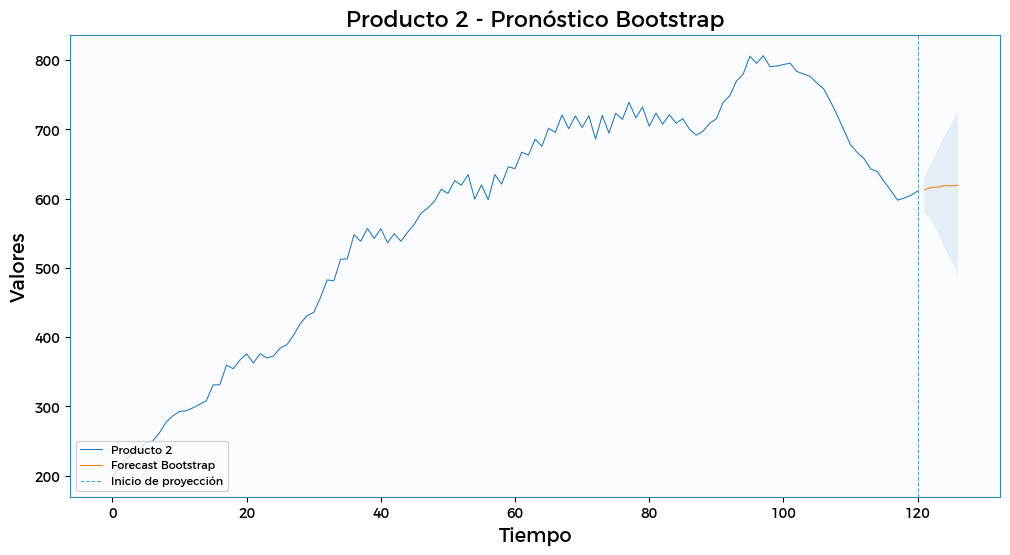

In [ ]:
fig = plt.figure()  
plt.plot(range(len(train_to2)), train_to2["producto2"], label="Producto 2")
plt.plot(preds_bootstrap_p2.index, preds_bootstrap_p2['Point_forecast'], label="Forecast Bootstrap")
plt.axvline(len(train_to2)-1, linestyle='--', alpha=0.7, label='Inicio de proyección')
plt.fill_between(preds_bootstrap_p2.index, preds_bootstrap_p2['lower_95'], preds_bootstrap_p2['upper_95'], alpha=0.1)
plt.title("Producto 2 - Pronóstico Bootstrap")
plt.xlabel("Tiempo")
plt.ylabel("Valores")
plt.legend(loc="lower left")
plt.show()

In [ ]:
# Calcular RMSE comparando predicciones bootstrap con datos de prueba
print("Datos reales (test):")
print(test_to2["producto2"].values)
print("\nPredicciones bootstrap:")
print(preds_bootstrap_p2['Point_forecast'].values)

# Calcular RMSE
from sklearn.metrics import mean_squared_error
rmse_bootstrap_p2 = np.sqrt(mean_squared_error(test_to2["producto2"].values, preds_bootstrap_p2['Point_forecast'].values))

print(f"\nRMSE del modelo bootstrap: {rmse_bootstrap_p2:.2f}")

Datos reales (test):
[624.5021022 629.2930339 637.0994671 653.1552818 672.5283447 676.0580921]

Predicciones bootstrap:
[612.67675672 616.40239515 616.73290048 618.91563774 618.44826241
 619.61023494]

RMSE del modelo bootstrap: 36.52


In [ ]:
# Comparación de modelos
print("="*60)
print("COMPARACIÓN DE MODELOS")
print("="*60)

# Del modelo autoarima (primera predicción)
print(f"MODELO AUTOARIMA:")
print(f"  RMSE: {rmse_autoarima_p2:.2f}")
print()

# Del modelo bootstrap 
print(f"MODELO BOOTSTRAP ARIMA(2,2,1):")
print(f"  RMSE: {rmse_bootstrap_p2:.2f}")

COMPARACIÓN DE MODELOS
MODELO AUTOARIMA:
  RMSE: 36.52

MODELO BOOTSTRAP ARIMA(2,2,1):
  RMSE: 36.52


## 11. OPTIMIZACIÓN BAYESIANA CON OPTUNA

In [ ]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

def objective_p2(trial):
    p = trial.suggest_int("p", 1, 10)
    d = trial.suggest_int("d", 1, 2)
    q = trial.suggest_int("q", 1, 10)
    window = trial.suggest_int("window", 6, 36)

    order = (p, d, q)
    return evaluar_expanding_forecast(train_to2["producto2"], order, window=window, step_size=1, horizon=1)


study_p2 = optuna.create_study(direction="minimize")
study_p2.optimize(objective_p2, n_trials=100)

print("\nMejores hiperparámetros:")
print(f"  p = {study_p2.best_params['p']}")
print(f"  d = {study_p2.best_params['d']}")
print(f"  q = {study_p2.best_params['q']}")
print(f"  window = {study_p2.best_params['window']}")
print(f"  RMSE = {study_p2.best_value:.4f}")

[I 2025-12-06 21:51:31,019] A new study created in memory with name: no-name-e749538e-83c8-4443-b9fd-534cd6fd538b
[I 2025-12-06 21:51:33,120] Trial 0 finished with value: 8.50179323120083 and parameters: {'p': 3, 'd': 1, 'q': 2, 'window': 12}. Best is trial 0 with value: 8.50179323120083.
[I 2025-12-06 21:51:33,120] Trial 0 finished with value: 8.50179323120083 and parameters: {'p': 3, 'd': 1, 'q': 2, 'window': 12}. Best is trial 0 with value: 8.50179323120083.
[I 2025-12-06 21:51:44,944] Trial 1 finished with value: 11.036820020128296 and parameters: {'p': 3, 'd': 2, 'q': 9, 'window': 22}. Best is trial 0 with value: 8.50179323120083.
[I 2025-12-06 21:51:44,944] Trial 1 finished with value: 11.036820020128296 and parameters: {'p': 3, 'd': 2, 'q': 9, 'window': 22}. Best is trial 0 with value: 8.50179323120083.
[I 2025-12-06 21:51:56,761] Trial 2 finished with value: 11.607109936852495 and parameters: {'p': 8, 'd': 2, 'q': 8, 'window': 21}. Best is trial 0 with value: 8.50179323120083.



Mejores hiperparámetros:
  p = 3
  d = 1
  q = 1
  window = 11
  RMSE = 8.1264


In [ ]:
# Visualización de resultados de optimización
from optuna.visualization import (plot_optimization_history, plot_param_importances, 
                                   plot_slice, plot_contour, plot_parallel_coordinate, plot_edf)

# 1. Historial de convergencia
fig1_p2 = plot_optimization_history(study_p2)
fig1_p2.update_layout(title="Historial de Convergencia")
fig1_p2.show()

# 2. Importancia de parámetros
fig2_p2 = plot_param_importances(study_p2)
fig2_p2.update_layout(title="Importancia de Hiperparámetros")
fig2_p2.show()

# 3. Efecto individual de cada parámetro
fig3_p2 = plot_slice(study_p2)
fig3_p2.update_layout(title="Efecto Individual de Parámetros")
fig3_p2.show()

# 4. Relación entre pares de parámetros
fig4_p2 = plot_contour(study_p2, params=["p", "q"])
fig4_p2.update_layout(title="Interacción entre p y q")
fig4_p2.show()

# 5. Coordenadas paralelas
fig5_p2 = plot_parallel_coordinate(study_p2)
fig5_p2.update_layout(title="Coordenadas Paralelas de Hiperparámetros")
fig5_p2.show()

# 6. Distribución empírica acumulada
fig6_p2 = plot_edf(study_p2)
fig6_p2.update_layout(title="Distribución Empírica (EDF) de RMSE")
fig6_p2.show()

## 9. MODELO ÓPTIMO CON DATASET COMPLETO

In [ ]:
# Ajustar modelo con los parámetros óptimos encontrados por Optuna
best_order_p2 = (study_p2.best_params['p'], study_p2.best_params['d'], study_p2.best_params['q'])

print(f"Ajustando modelo ARIMA{best_order_p2} con dataset completo...")
model_optimo_p2 = ARIMA(data['producto2'], order=best_order_p2)
results_optimo_p2 = model_optimo_p2.fit()

print(f"\nModelo óptimo ajustado: ARIMA{best_order_p2}")
results_optimo_p2.summary()

Ajustando modelo ARIMA(3, 1, 1) con dataset completo...

Modelo óptimo ajustado: ARIMA(3, 1, 1)

Modelo óptimo ajustado: ARIMA(3, 1, 1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              producto2   No. Observations:                  127
Model:                 ARIMA(3, 1, 1)   Log Likelihood                -466.053
Date:               sáb, 06 dic. 2025   AIC                            942.107
Time:                        22:19:25   BIC                            956.288
Sample:                             0   HQIC                           947.868
                                - 127                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5634      1.688      0.334      0.739      -2.744       3.871
ar.L2          0.8036      0.114      7.020      0.000       0.579       1.028
ar.L3         -0.4876      1.292     -0.378      0.706      -3.019       2.044
ma.L1         -0.5934      1.718     -0.345      0.730      -3.961       2.774
sigma2        94.1346     12.277      7.668      0.000      70.073     118.197
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):                 0.69
Prob(Q):                              0.77   Prob(JB):                         0.71
Heteroskedasticity (H):               0.98   Skew:                            -0.18
Prob(H) (two-sided):                  0.96   Kurtosis:                         3.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

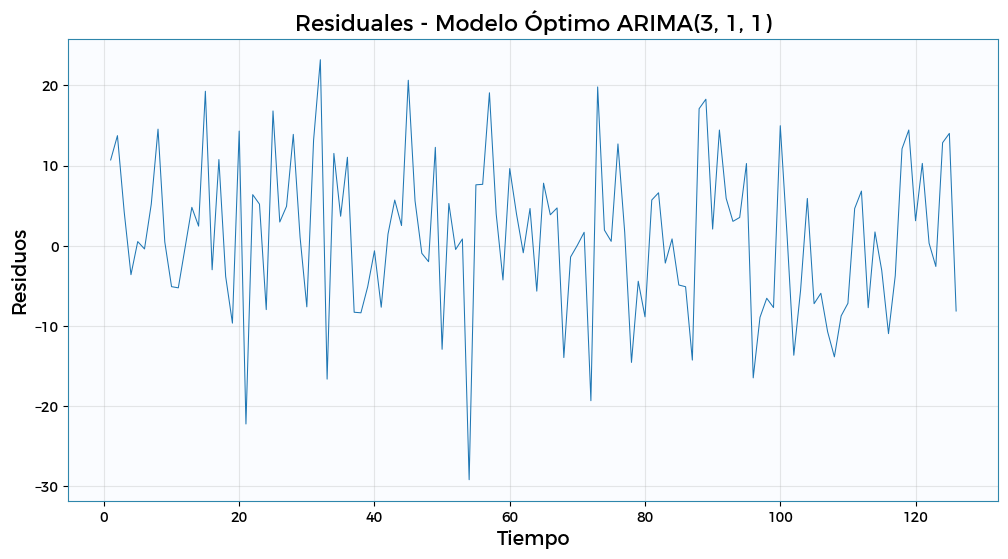

In [ ]:
residuos_optimo_p2 = results_optimo_p2.resid[study_p2.best_params['d']:]

fig = plt.figure()
plt.plot(residuos_optimo_p2)
plt.title(f"Residuales - Modelo Óptimo ARIMA{best_order_p2}")
plt.xlabel("Tiempo")
plt.ylabel("Residuos")
plt.grid(True, alpha=0.3)
plt.show()

## 10. VALIDACIÓN DE SUPUESTOS DEL MODELO ÓPTIMO

=== VALIDACIÓN DE SUPUESTOS - MODELO ARIMA(3, 1, 1) ===

=== AUTOCORRELACIÓN ===
Test Ljung-Box: p-valor = 0.906293
✓ No hay autocorrelación


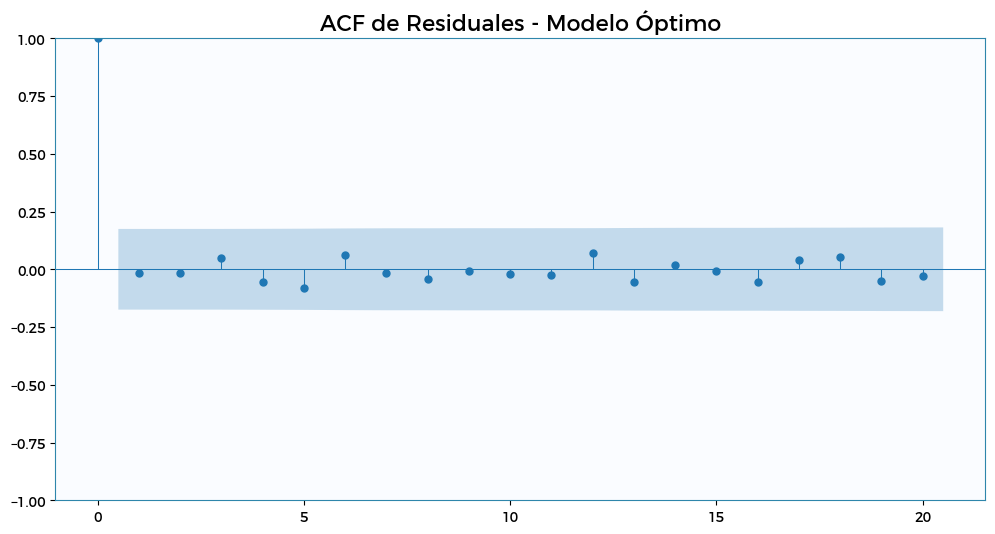

In [ ]:
# 1. SUPUESTO: NO AUTOCORRELACIÓN
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import pandas as pd

print(f"=== VALIDACIÓN DE SUPUESTOS - MODELO ARIMA{best_order_p2} ===\n")
print("=== AUTOCORRELACIÓN ===")
ljung_autocorr_opt_p2 = acorr_ljungbox(residuos_optimo_p2, lags=24)['lb_pvalue'].iloc[-1]
print(f"Test Ljung-Box: p-valor = {ljung_autocorr_opt_p2:.6f}")

if ljung_autocorr_opt_p2 > 0.05:
    print("✓ No hay autocorrelación")
else:
    print("✗ HAY autocorrelación")
    
# Gráfico ACF
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuos_optimo_p2, lags=20, title="ACF de Residuales - Modelo Óptimo")
plt.show()

=== NORMALIDAD ===
Test Shapiro-Wilk: p-valor = 0.676868
Test Jarque-Bera: p-valor = 0.714484
✓ Los residuales son normales


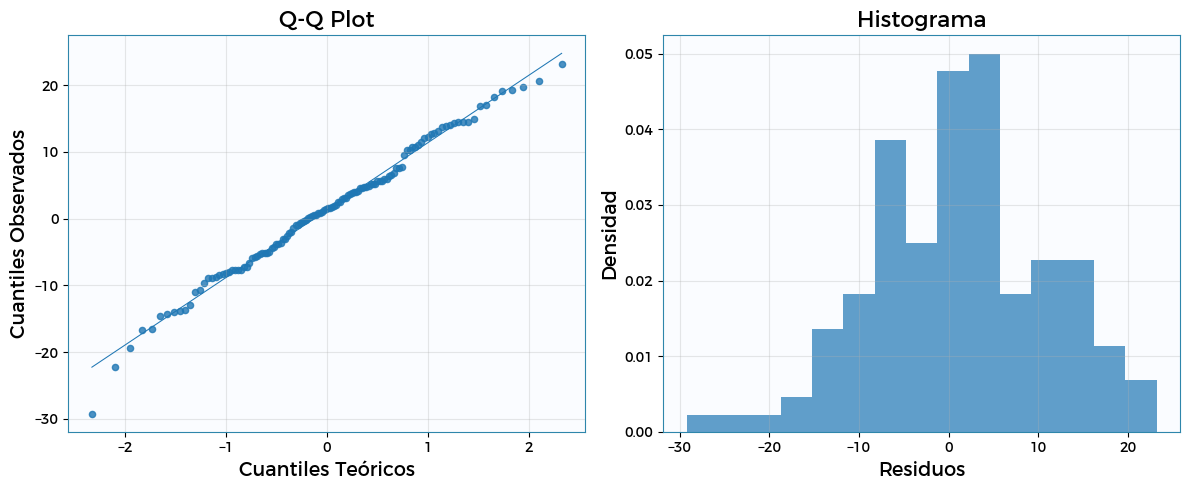

In [ ]:
# 2. SUPUESTO: NORMALIDAD
print("=== NORMALIDAD ===")

# Shapiro-Wilk
shapiro_pvalue_opt_p2 = stats.shapiro(residuos_optimo_p2)[1]
print(f"Test Shapiro-Wilk: p-valor = {shapiro_pvalue_opt_p2:.6f}")

# Jarque-Bera
jb_pvalue_opt_p2 = stats.jarque_bera(residuos_optimo_p2)[1]
print(f"Test Jarque-Bera: p-valor = {jb_pvalue_opt_p2:.6f}")

if shapiro_pvalue_opt_p2 > 0.05 and jb_pvalue_opt_p2 > 0.05:
    print("✓ Los residuales son normales")
else:
    print("✗ Los residuales NO son normales")

# Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q Plot
sorted_residuos_opt_p2 = np.sort(residuos_optimo_p2)
n_opt_p2 = len(sorted_residuos_opt_p2)
theoretical_quantiles_opt_p2 = stats.norm.ppf(np.linspace(0.01, 0.99, n_opt_p2))

ax1.scatter(theoretical_quantiles_opt_p2, sorted_residuos_opt_p2, alpha=0.8, s=20)
slope_opt_p2, intercept_opt_p2 = np.polyfit(theoretical_quantiles_opt_p2, sorted_residuos_opt_p2, 1)
ax1.plot(theoretical_quantiles_opt_p2, slope_opt_p2 * theoretical_quantiles_opt_p2 + intercept_opt_p2)
ax1.set_xlabel("Cuantiles Teóricos")
ax1.set_ylabel("Cuantiles Observados")
ax1.set_title("Q-Q Plot")
ax1.grid(True, alpha=0.3)

# Histograma
ax2.hist(residuos_optimo_p2, bins=15, density=True, alpha=0.7)
ax2.set_title("Histograma")
ax2.set_xlabel("Residuos")
ax2.set_ylabel("Densidad")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== HOMOSCEDASTICIDAD ===
Test Ljung-Box (res²): p-valor = 0.732050
Test Breusch-Pagan: p-valor = 0.688860
✓ Varianza constante (homoscedasticidad)


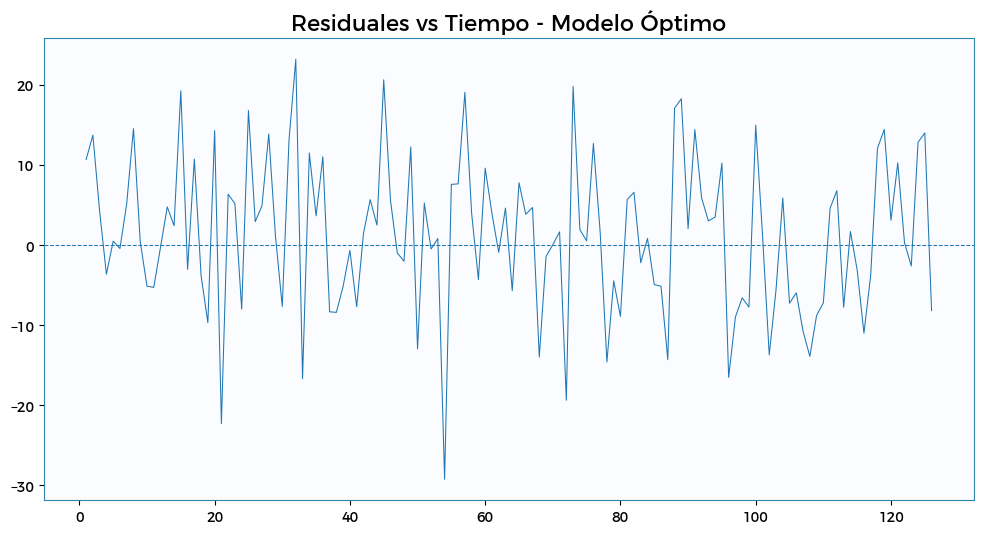

In [ ]:
# 3. SUPUESTO: HOMOSCEDASTICIDAD
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

print("=== HOMOSCEDASTICIDAD ===")

# Ljung-Box en residuos²
ljung_hetero_opt_p2 = acorr_ljungbox(residuos_optimo_p2**2, lags=10)['lb_pvalue'].iloc[-1]
print(f"Test Ljung-Box (res²): p-valor = {ljung_hetero_opt_p2:.6f}")

# Breusch-Pagan
tiempo_opt_p2 = np.arange(len(residuos_optimo_p2)).reshape(-1, 1)
tiempo_const_opt_p2 = sm.add_constant(tiempo_opt_p2)
bp_pvalue_opt_p2 = het_breuschpagan(residuos_optimo_p2, tiempo_const_opt_p2)[1]
print(f"Test Breusch-Pagan: p-valor = {bp_pvalue_opt_p2:.6f}")

if ljung_hetero_opt_p2 > 0.05 and bp_pvalue_opt_p2 > 0.05:
    print("✓ Varianza constante (homoscedasticidad)")
else:
    print("✗ Varianza NO constante (heteroscedasticidad)")

# Gráfico
plt.figure()
plt.plot(residuos_optimo_p2)
plt.axhline(y=0, linestyle='--')
plt.title("Residuales vs Tiempo - Modelo Óptimo")
plt.show()

In [ ]:
# RESUMEN: Tabla de resultados
resultados_optimo_p2 = pd.DataFrame({
    'Supuesto': ['No Autocorrelación', 'Normalidad', 'Normalidad', 'Homoscedasticidad', 'Homoscedasticidad'],
    'Prueba': ['Ljung-Box', 'Shapiro-Wilk', 'Jarque-Bera', 'Ljung-Box (res²)', 'Breusch-Pagan'],
    'P-valor': [ljung_autocorr_opt_p2, shapiro_pvalue_opt_p2, jb_pvalue_opt_p2, ljung_hetero_opt_p2, bp_pvalue_opt_p2],
    'Cumple': ['✓' if ljung_autocorr_opt_p2 > 0.05 else '✗',
               '✓' if shapiro_pvalue_opt_p2 > 0.05 else '✗',
               '✓' if jb_pvalue_opt_p2 > 0.05 else '✗',
               '✓' if ljung_hetero_opt_p2 > 0.05 else '✗',
               '✓' if bp_pvalue_opt_p2 > 0.05 else '✗']
})

print(f"\nTABLA RESUMEN DE SUPUESTOS - MODELO ARIMA{best_order_p2}:")
print(resultados_optimo_p2.to_string(index=False))


TABLA RESUMEN DE SUPUESTOS - MODELO ARIMA(3, 1, 1):
          Supuesto           Prueba  P-valor Cumple
No Autocorrelación        Ljung-Box 0.906293      ✓
        Normalidad     Shapiro-Wilk 0.676868      ✓
        Normalidad      Jarque-Bera 0.714484      ✓
 Homoscedasticidad Ljung-Box (res²) 0.732050      ✓
 Homoscedasticidad    Breusch-Pagan 0.688860      ✓


## 11. VALIDACIÓN CON VENTANA MÓVIL - MODELO ÓPTIMO

### Ventana Fija vs Ventana Móvil

**Ventana Fija:**
- Entrena con todos los datos de entrenamiento
- Predice todos los datos de prueba a la vez

**Ventana Móvil:**
- Usa una ventana fija que se desplaza
- En cada paso: entrena con los últimos N datos y predice 1 paso adelante
- Simula mejor la predicción en tiempo real

VALIDACIÓN CON VENTANA MÓVIL - MODELO ARIMA(3, 1, 1)

RESULTADOS:
  RMSE Auto-ARIMA (Ventana Fija):      36.5244
  RMSE ARIMA Manual (Ventana Fija):    36.5244
  RMSE Ventana Móvil (Óptima):         12.5982
  Ventana utilizada: 11

RESULTADOS:
  RMSE Auto-ARIMA (Ventana Fija):      36.5244
  RMSE ARIMA Manual (Ventana Fija):    36.5244
  RMSE Ventana Móvil (Óptima):         12.5982
  Ventana utilizada: 11


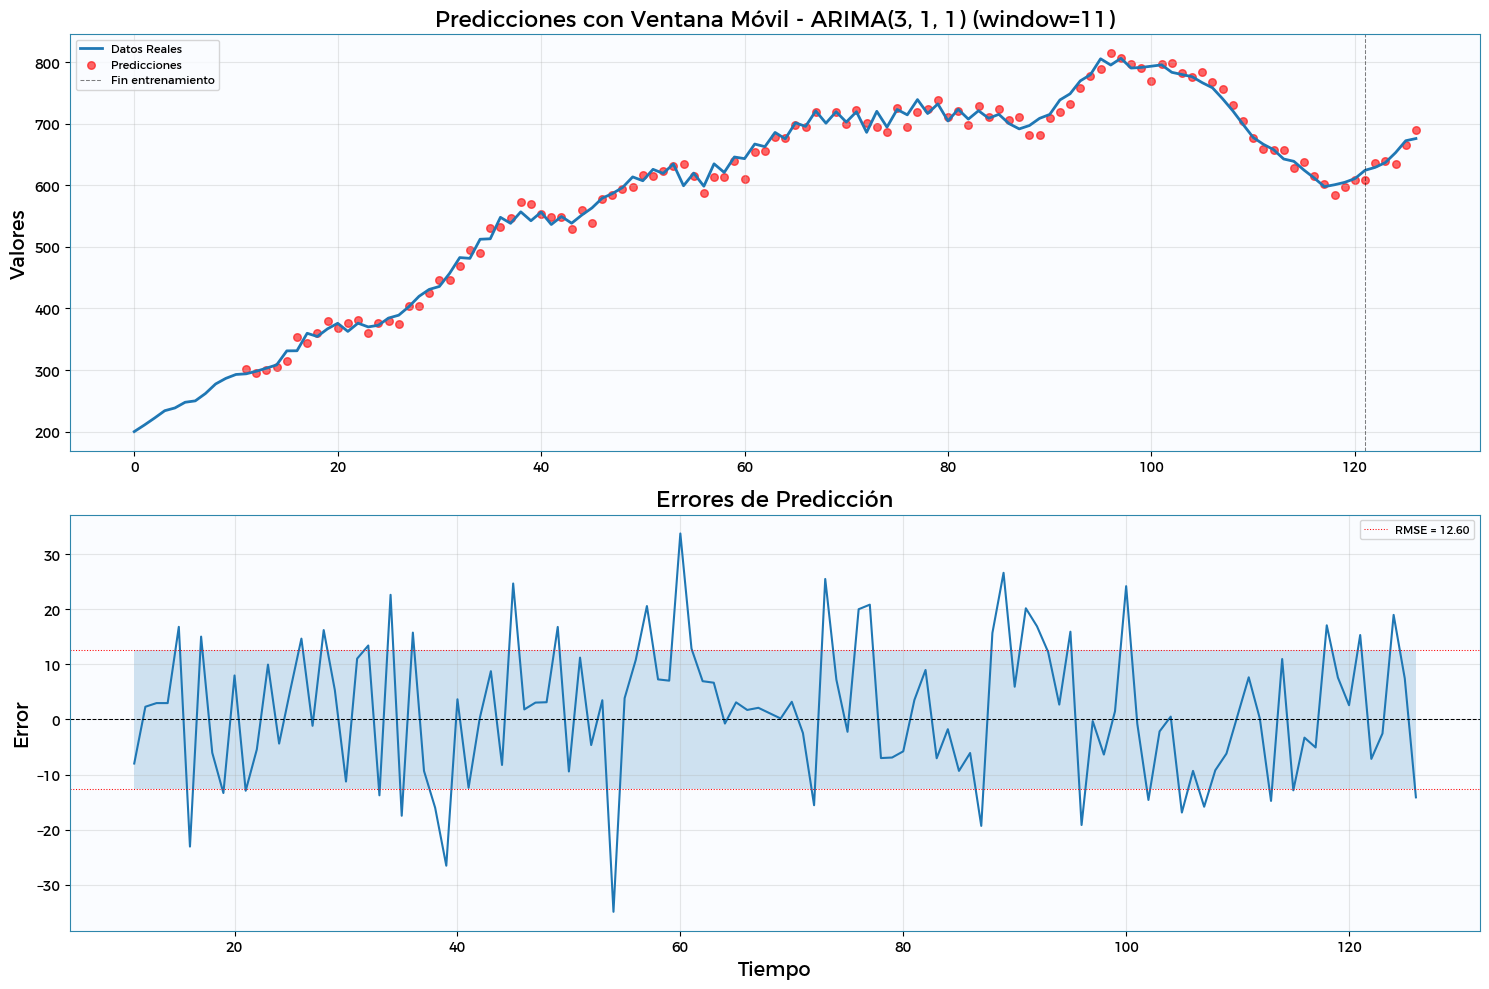

In [ ]:
# Validación con ventana móvil usando parámetros óptimos
print(f"VALIDACIÓN CON VENTANA MÓVIL - MODELO ARIMA{best_order_p2}")
print("="*60)

# Configuración con la ventana óptima de Optuna
window_size_opt_p2 = study_p2.best_params['window']
datos_completos_p2 = pd.concat([train_to2['producto2'], test_to2['producto2']])

# Almacenar predicciones
predicciones_rolling_opt_p2 = []
valores_reales_rolling_opt_p2 = []
indices_prediccion_opt_p2 = []

# Iterar con ventana móvil
for i in range(len(datos_completos_p2) - window_size_opt_p2):
    train_window_opt_p2 = datos_completos_p2.iloc[i:i+window_size_opt_p2]
    valor_real_opt_p2 = datos_completos_p2.iloc[i+window_size_opt_p2]
    
    try:
        model_rolling_opt_p2 = ARIMA(train_window_opt_p2, order=best_order_p2)
        results_rolling_opt_p2 = model_rolling_opt_p2.fit()
        pred_opt_p2 = results_rolling_opt_p2.forecast(steps=1).iloc[0]
        
        predicciones_rolling_opt_p2.append(pred_opt_p2)
        valores_reales_rolling_opt_p2.append(valor_real_opt_p2)
        indices_prediccion_opt_p2.append(i + window_size_opt_p2)
    except:
        continue

# Convertir a arrays
predicciones_rolling_opt_p2 = np.array(predicciones_rolling_opt_p2)
valores_reales_rolling_opt_p2 = np.array(valores_reales_rolling_opt_p2)

# Calcular RMSE
rmse_rolling_opt_p2 = np.sqrt(mean_squared_error(valores_reales_rolling_opt_p2, predicciones_rolling_opt_p2))

print(f"\nRESULTADOS:")
print(f"  RMSE Auto-ARIMA (Ventana Fija):      {rmse_autoarima_p2:.4f}")
print(f"  RMSE ARIMA Manual (Ventana Fija):    {rmse_manual_p2:.4f}")
print(f"  RMSE Ventana Móvil (Óptima):         {rmse_rolling_opt_p2:.4f}")
print(f"  Ventana utilizada: {window_size_opt_p2}")
print("="*60)

# Gráficos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Serie completa con predicciones
ax1.plot(range(len(datos_completos_p2)), datos_completos_p2.values, 
         label='Datos Reales', linewidth=2)
ax1.scatter(indices_prediccion_opt_p2, predicciones_rolling_opt_p2, 
           label='Predicciones', color='red', s=30, alpha=0.6)
ax1.axvline(x=len(train_to2), linestyle='--', color='black', 
           alpha=0.5, label='Fin entrenamiento')
ax1.set_title(f'Predicciones con Ventana Móvil - ARIMA{best_order_p2} (window={window_size_opt_p2})')
ax1.set_ylabel('Valores')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Errores
errores_rolling_opt_p2 = valores_reales_rolling_opt_p2 - predicciones_rolling_opt_p2
ax2.plot(indices_prediccion_opt_p2, errores_rolling_opt_p2, linewidth=1.5)
ax2.axhline(y=0, color='black', linestyle='--')
ax2.axhline(y=rmse_rolling_opt_p2, color='red', linestyle=':', label=f'RMSE = {rmse_rolling_opt_p2:.2f}')
ax2.axhline(y=-rmse_rolling_opt_p2, color='red', linestyle=':')
ax2.fill_between(indices_prediccion_opt_p2, -rmse_rolling_opt_p2, rmse_rolling_opt_p2, alpha=0.2)
ax2.set_title('Errores de Predicción')
ax2.set_xlabel('Tiempo')
ax2.set_ylabel('Error')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. COMPARACIÓN FINAL DE TODOS LOS MODELOS ARIMA

In [ ]:
# Tabla comparativa de todos los modelos ARIMA
comparacion_modelos = pd.DataFrame({
    'Producto': ['Producto 1', 'Producto 1', 'Producto 1', 'Producto 1', 
                 'Producto 2', 'Producto 2', 'Producto 2', 'Producto 2'],
    'Modelo': ['Auto-ARIMA', 'ARIMA(2,1,2) Manual', 'ARIMA(2,1,2) Bootstrap', 'ARIMA Óptimo (Optuna) - Ventana Móvil',
               'Auto-ARIMA', 'ARIMA(2,2,1) Manual', 'ARIMA(2,2,1) Bootstrap', 'ARIMA Óptimo (Optuna) - Ventana Móvil'],
    'Tipo de Validación': ['Ventana Fija', 'Ventana Fija', 'Ventana Fija', f'Ventana Móvil (window={window_size_opt})',
                          'Ventana Fija', 'Ventana Fija', 'Ventana Fija', f'Ventana Móvil (window={window_size_opt_p2})'],
    'Orden ARIMA': [str(model_total.order), '(2,1,2)', '(2,1,2)', str(best_order),
                    str(model_total_p2.order), '(2,2,1)', '(2,2,1)', str(best_order_p2)],
    'RMSE': [rmse_autoarima, rmse_manual, rmse_bootstrap, rmse_rolling_opt,
             rmse_autoarima_p2, rmse_manual_p2, rmse_bootstrap_p2, rmse_rolling_opt_p2],
    'Método': ['auto_arima', 'ARIMA manual', 'Bootstrap (IC 95%)', 'Optuna + Rolling',
               'auto_arima', 'ARIMA manual', 'Bootstrap (IC 95%)', 'Optuna + Rolling']
})

# Ordenar por producto y RMSE
comparacion_modelos = comparacion_modelos.sort_values(['Producto', 'RMSE']).reset_index(drop=True)

print("="*100)
print("COMPARACIÓN COMPLETA DE MODELOS ARIMA")
print("="*100)
print(comparacion_modelos.to_string(index=False))
print("="*100)

# Resumen por producto
print("\nRESUMEN POR PRODUCTO:")
print("-"*100)
for producto in ['Producto 1', 'Producto 2']:
    subset = comparacion_modelos[comparacion_modelos['Producto'] == producto]
    mejor = subset.iloc[0]
    print(f"\n{producto}:")
    print(f"  Mejor modelo: {mejor['Modelo']} ({mejor['Tipo de Validación']})")
    print(f"  RMSE: {mejor['RMSE']:.4f}")
    print(f"  Orden: {mejor['Orden ARIMA']}")
print("="*100)

COMPARACIÓN COMPLETA DE MODELOS ARIMA
  Producto                                Modelo        Tipo de Validación Orden ARIMA      RMSE             Método
Producto 1                            Auto-ARIMA              Ventana Fija   (2, 1, 2)  5.266239         auto_arima
Producto 1                   ARIMA(2,1,2) Manual              Ventana Fija     (2,1,2)  7.778719       ARIMA manual
Producto 1                ARIMA(2,1,2) Bootstrap              Ventana Fija     (2,1,2)  7.778719 Bootstrap (IC 95%)
Producto 1 ARIMA Óptimo (Optuna) - Ventana Móvil Ventana Móvil (window=20)   (6, 2, 7)  9.106204   Optuna + Rolling
Producto 2 ARIMA Óptimo (Optuna) - Ventana Móvil Ventana Móvil (window=11)   (3, 1, 1) 12.598194   Optuna + Rolling
Producto 2                            Auto-ARIMA              Ventana Fija   (2, 2, 1) 36.524361         auto_arima
Producto 2                   ARIMA(2,2,1) Manual              Ventana Fija     (2,2,1) 36.524361       ARIMA manual
Producto 2                ARIMA(2,

In [ ]:
# Resumen de optimización Optuna para ambos productos
print("="*100)
print("RESULTADOS DE OPTIMIZACIÓN BAYESIANA CON OPTUNA")
print("="*100)
print("\nPRODUCTO 1:")
print(f"  Mejores hiperparámetros: p={study.best_params['p']}, d={study.best_params['d']}, q={study.best_params['q']}, window={study.best_params['window']}")
print(f"  RMSE optimizado: {study.best_value:.4f}")
print(f"  Número de trials: {len(study.trials)}")

print("\nPRODUCTO 2:")
print(f"  Mejores hiperparámetros: p={study_p2.best_params['p']}, d={study_p2.best_params['d']}, q={study_p2.best_params['q']}, window={study_p2.best_params['window']}")
print(f"  RMSE optimizado: {study_p2.best_value:.4f}")
print(f"  Número de trials: {len(study_p2.trials)}")
print("="*100)

RESULTADOS DE OPTIMIZACIÓN BAYESIANA CON OPTUNA

PRODUCTO 1:
  Mejores hiperparámetros: p=6, d=2, q=7, window=20
  RMSE optimizado: 6.6554
  Número de trials: 100

PRODUCTO 2:
  Mejores hiperparámetros: p=3, d=1, q=1, window=11
  RMSE optimizado: 8.1264
  Número de trials: 100


In [ ]:
import pickle

# Guardar todos los resultados en un archivo pkl
resultados_arima = {
    # Producto 1
    'producto1': {
        'best_order': best_order,
        'model_optimo': model_optimo,
        'results_optimo': results_optimo,
        'residuos_optimo': residuos_optimo,
        'window_size_opt': window_size_opt,
        'rmse_rolling_opt': rmse_rolling_opt,
        'predicciones_rolling_opt': predicciones_rolling_opt,
        'valores_reales_rolling_opt': valores_reales_rolling_opt,
        'indices_prediccion_opt': indices_prediccion_opt,
        'errores_rolling_opt': errores_rolling_opt,
        'resultados_optimo': resultados_optimo,
        'rmse_autoarima': rmse_autoarima,
        'rmse_manual': rmse_manual
    },
    # Producto 2
    'producto2': {
        'best_order': best_order_p2,
        'model_optimo': model_optimo_p2,
        'results_optimo': results_optimo_p2,
        'residuos_optimo': residuos_optimo_p2,
        'window_size_opt': window_size_opt_p2,
        'rmse_rolling_opt': rmse_rolling_opt_p2,
        'predicciones_rolling_opt': predicciones_rolling_opt_p2,
        'valores_reales_rolling_opt': valores_reales_rolling_opt_p2,
        'indices_prediccion_opt': indices_prediccion_opt_p2,
        'errores_rolling_opt': errores_rolling_opt_p2,
        'resultados_optimo': resultados_optimo_p2,
        'rmse_autoarima': rmse_autoarima_p2,
        'rmse_manual': rmse_manual_p2
    },
    # Datos
    'datos': {
        'data': data,
        'train_to1': train_to1,
        'test_to1': test_to1,
        'train_to2': train_to2,
        'test_to2': test_to2,
        'datos_completos': datos_completos,
        'datos_completos_p2': datos_completos_p2
    },
    # Comparación final
    'comparacion': comparacion_modelos
}

with open('resultados_ARIMA.pkl', 'wb') as f:
    pickle.dump(resultados_arima, f)

print("Resultados guardados en 'resultados_ARIMA.pkl'")

Resultados guardados en 'resultados_ARIMA.pkl'
